# Opening the parquet files

In [130]:
pip install duckdb pandas

In [132]:
import duckdb

file_path = r"C:\Users\20232379\OneDrive - TU Eindhoven\Desktop\MCBL\crimes_clean_dedup_all_years.parquet"

result = duckdb.sql(f"""
    SELECT *
    FROM '{file_path}'
    LIMIT 10
""").df()

print(result)

     Month             Falls within  Longitude   Latitude  LSOA code  \
0  2013-05  Derbyshire Constabulary  -1.359885  53.014737  E01019438   
1  2013-05  Derbyshire Constabulary  -1.486916  52.981598  E01019426   
2  2013-05  Derbyshire Constabulary  -1.591089  52.941784  E01019472   
3  2013-05  Derbyshire Constabulary  -1.353828  53.005095  E01019437   
4  2013-05  Derbyshire Constabulary  -1.340087  53.022782  E01019452   
5  2013-05  Derbyshire Constabulary  -1.205877  53.283961  E01019524   
6  2013-05  Derbyshire Constabulary  -1.202337  53.286382  E01019523   
7  2013-05  Derbyshire Constabulary  -1.292167  53.229537  E01019483   
8  2013-05  Derbyshire Constabulary  -1.301516  53.228540  E01019488   
9  2013-05  Derbyshire Constabulary  -1.229466  53.204122  E01019512   

           LSOA name                 Crime type  
0  Amber Valley 012C                Shoplifting  
1  Amber Valley 016B                   Burglary  
2  Amber Valley 016D      Anti-social behaviour  
3  Ambe

In [134]:
file_path = r"C:\Users\20232379\OneDrive - TU Eindhoven\Desktop\MCBL\crimes_clean_dedup_all_years.parquet"

print(
    duckdb.sql(f"""
        DESCRIBE
        SELECT * FROM '{file_path}'
    """).df()
)

    column_name column_type null   key default extra
0         Month     VARCHAR  YES  None    None  None
1  Falls within     VARCHAR  YES  None    None  None
2     Longitude     VARCHAR  YES  None    None  None
3      Latitude     VARCHAR  YES  None    None  None
4     LSOA code     VARCHAR  YES  None    None  None
5     LSOA name     VARCHAR  YES  None    None  None
6    Crime type     VARCHAR  YES  None    None  None


# 1. Kolmogorov–Smirnov (KS) Test

In [136]:
pip install pandas scipy pyarrow

Note: you may need to restart the kernel to use updated packages.


In [138]:
import pandas as pd
from scipy.stats import ks_2samp

file_path = r"C:\Users\20232379\OneDrive - TU Eindhoven\Desktop\MCBL\crimes_clean_dedup_all_years.parquet"

df = pd.read_parquet(file_path)

df['Month'] = pd.to_datetime(df['Month'])
df['year'] = df['Month'].dt.year

monthly_counts = (
    df.groupby('Month')
      .size()
      .reset_index(name='crime_count')
)

monthly_counts['year'] = monthly_counts['Month'].dt.year

period1 = monthly_counts[
    (monthly_counts['year'] >= 2012) &
    (monthly_counts['year'] <= 2019)
]['crime_count']

period2 = monthly_counts[
    (monthly_counts['year'] >= 2022) &
    (monthly_counts['year'] <= 2025)
]['crime_count']

In [140]:
ks_stat, p_value = ks_2samp(period1, period2)

print("KS Statistic:", ks_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference between periods")
else:
    print("No significant difference between periods")

KS Statistic: 0.3125
P-value: 0.003390083064385512
Significant difference between periods


#### Short explanation:
The Kolmogorov–Smirnov test revealed a statistically significant difference in the distribution of monthly crime counts between the 2012–2019 and 2022–2025 periods (KS = 0.313, p = 0.003). In fact, the null hypothesis that crime distributions in the two periods were drawn from the same population distribution was rejected. 
Furthermore, the KS statistic represents the maximum vertical distance between the empirical cumulative distribution functions (ECDFs) of the two samples. A value around:

- 0: very similar distributions
- 1: completely different distributions

So 0.31 suggests a moderate distributional shift.

**N.B.**
- p = 0.003: if the two periods actually had identical distributions, there would be only a 0.3% chance of observing a difference this large due to random sampling variation alone
- D = 0.31: the maximum vertical separation between the two cumulative distributions is about 31%.

# 2. Mann-Whitney U Test

In [77]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    period1,
    period2,
    alternative='two-sided'
)

print("U statistic:", u_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference between periods")
else:
    print("No significant difference between periods")

U statistic: 3107.0
P-value: 0.0006716138053065197
Significant difference between periods


In [79]:
print("Median 2012-2019:", period1.median())
print("Median 2022-2025:", period2.median())

Median 2012-2019: 363048.5
Median 2022-2025: 349333.0


In [81]:
n1 = len(period1)
n2 = len(period2)

rbc = 1 - (2 * u_stat) / (n1 * n2)

print("Rank-biserial correlation:", rbc)

Rank-biserial correlation: -0.3485243055555556


#### Short explanation

The Mann-Whitney U Test checks whether observations from one group tend to rank higher than observations from the other. Overall, we see that monthly crime counts differ between 2012–2019 and 2022–2025 and the later period tends to have lower counts:
- The U statistic comes from ranking all monthly crime counts from both periods together, but it's not really intuitive and is used to compute the p-value and the effect size mostly. A high or low U value indicates that one period’s observations tend to rank above or below the other period’s observations.
- The p-value is well below 0.05, so the difference is statistically significant.
- Taking the difference between the two periods' monthly medians, the later period’s median monthly crime count was about 13,716 crimes lower. Therefore, the typical monthly count was about 3.8% lower in 2022–2025 (13,715.5 / 363,048.5 ≈ 3.8%).
- The negative sign in the rank-biserial correlation means the second period, 2022–2025, tends to have lower monthly crime counts than 2012–2019. The magnitude, about 0.35, suggests a moderate effect. So this is not just statistically significant; the difference is also meaningful in size.

## Combining the two tests
The KS test shows that the overall distributions differ, while the Mann–Whitney U test shows that the later period tends to have lower monthly crime counts.

# Adding some more descriptive statistics

In [248]:
print("2012-2019")
print(period1.describe())
print(f"median: {period1.median()}")

print("\n2022-2025")
print(period2.describe())
print(f"median: {period2.median()}")

2012-2019
count        96.000000
mean     365072.510417
std       29304.186085
min      299740.000000
25%      345701.750000
50%      363048.500000
75%      388425.750000
max      435452.000000
Name: crime_count, dtype: float64
median: 363048.5

2022-2025
count        48.000000
mean     347313.333333
std       21698.792874
min      300145.000000
25%      330583.500000
50%      349333.000000
75%      362909.250000
max      384399.000000
Name: crime_count, dtype: float64
median: 349333.0


# 3. Visualizing the data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

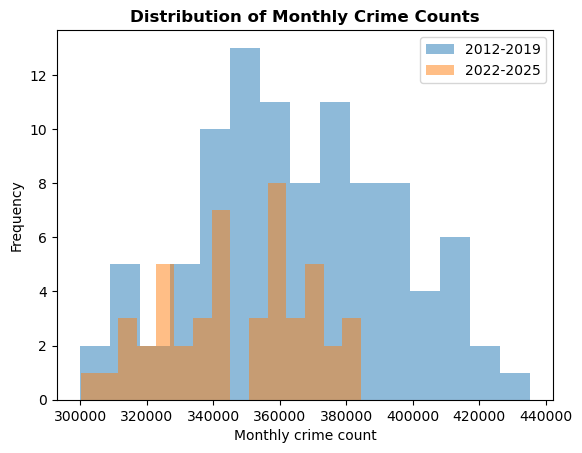

In [30]:
plt.hist(period1, bins=15, alpha=0.5, label='2012-2019')
plt.hist(period2, bins=15, alpha=0.5, label='2022-2025')

plt.xlabel('Monthly crime count')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Crime Counts', weight='bold')
plt.legend()

plt.show()

#### Short explanation 
Purpose of the visualization: how common were the different monthly crime-count levels in each period? The histogram shows that the 2012–2019 period generally had higher monthly crime counts and greater variability than the 2022–2025 period. In fact, monthly crime levels after 2022 appear systematically different from those observed during 2012–2019: overall crime counts may have decreased, the spread/variability of crime may also have changed and high-crime months became less common after 2022. Interpretation of the graph:

- Each value on the x-axis is the total number of crimes recorded in one month, aka size of the monthly total
- The y-axis shows how many months fall into each crime-count range

E.g. In the 2012–2019 period, there were about 10 months where the total monthly crime count was between roughly 340,000 and 350,000.


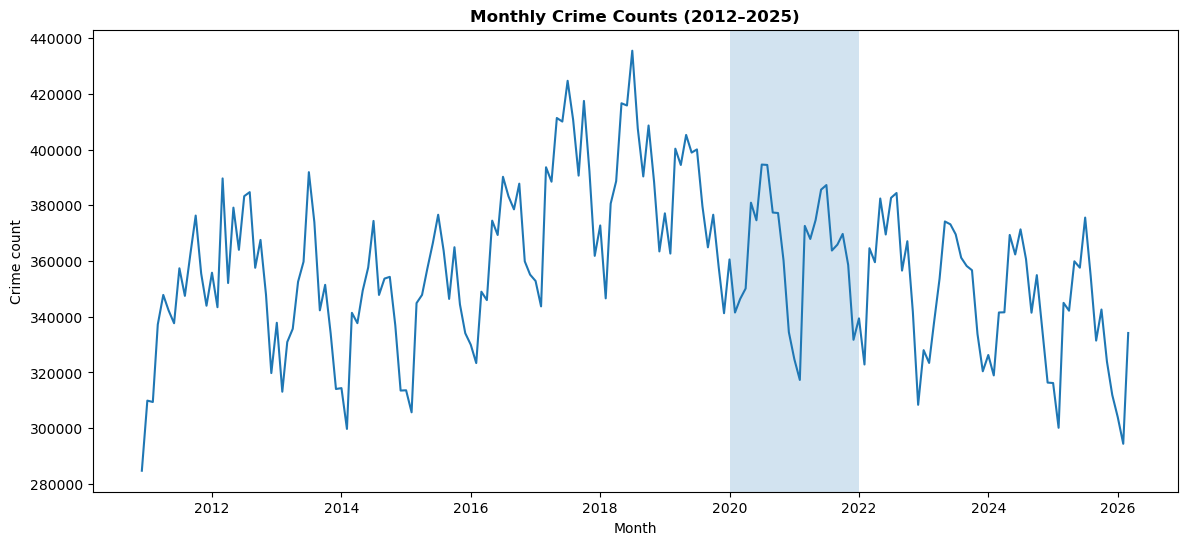

In [56]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_counts['Month'],
    monthly_counts['crime_count'],
    linewidth=1.5
)

# Shade excluded COVID years
plt.axvspan(
    pd.to_datetime('2020-01-01'),
    pd.to_datetime('2021-12-31'),
    alpha=0.2
)

plt.xlabel('Month')
plt.ylabel('Crime count')
plt.title('Monthly Crime Counts (2012–2025)', weight='bold')

plt.show()

#### Short explanation
Purpose: monthly crime counts can be visualized chronologically for interpreting distributional changes

- The x-axis shows all years present in the data, with 2020 and 2021 excluded as they were affected by lockdown periods
- The y-axis shows the monthly crime count

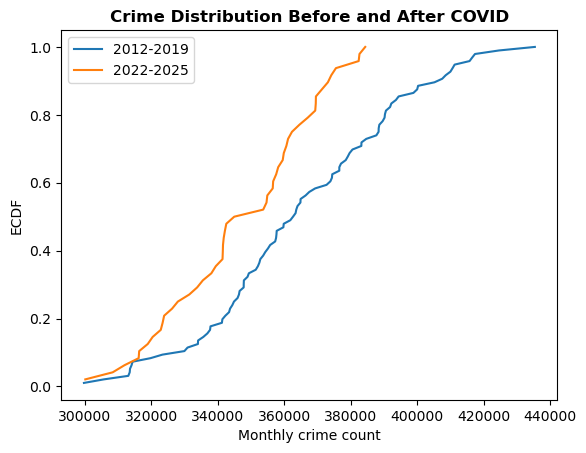

In [256]:
x1 = np.sort(period1)
y1 = np.arange(1, len(x1)+1) / len(x1)

x2 = np.sort(period2)
y2 = np.arange(1, len(x2)+1) / len(x2)

plt.plot(x1, y1, label='2012-2019')
plt.plot(x2, y2, label='2022-2025')

plt.xlabel('Monthly crime count')
plt.ylabel('ECDF')
plt.title('Crime Distribution Before and After COVID', weight='bold')
plt.legend()

plt.show()

#### Short description
The ECDF shows the proportion of months with crime counts less than or equal to a given value, where:

- x-axis = monthly crime count
- y-axis = cumulative proportion of months

Here, the orange curve lies mostly to the left and above the blue curve: this means that a larger proportion of post-2022 months had lower crime counts. In other words, monthly crime counts in 2022-2025 tended to be lower than in 2012-2019. We also see that:
- Extremely high-crime months were more common before 2020 as the blue line extends to even 440k
- The orange curve is rising more steeply, so counts may be more stable/with less variance
- The lines overlap but they are constitently separated, indicating a statistically significant but moderate distributional shift. 

For instance, we can see that approximately 50% of months had crime counts ≤ 350000 for the orange line, while for the blue line it was around 30%, so lower crime counts are much more common in the later period. This indicates a downward shift in the distribution.

We know that the KS statistic is the largest vertical distance between the two ECDF curves; in this plot it appears to be around 370000 and that maximum gap would be approximately 31%. Furthermore, the visual pattern is consistent with the significant Mann–Whitney U test result (p < 0.001), which suggests that monthly crime counts in 2022-2025 tend to be systematically lower than those observed in 2012-2019.

#### Extra

In [108]:
df

,Month,Falls within,Longitude,Latitude,LSOA code,LSOA name,Crime type,year
0,2013-05-01,Derbyshire Constabulary,-1.359885,53.014737,E01019438,Amber Valley 012C,Shoplifting,2013
1,2013-05-01,Derbyshire Constabulary,-1.486916,52.981598,E01019426,Amber Valley 016B,Burglary,2013
2,2013-05-01,Derbyshire Constabulary,-1.591089,52.941784,E01019472,Amber Valley 016D,Anti-social behaviour,2013
3,2013-05-01,Derbyshire Constabulary,-1.353828,53.005095,E01019437,Amber Valley 017A,Criminal damage and arson,2013
4,2013-05-01,Derbyshire Constabulary,-1.340087,53.022782,E01019452,Amber Valley 017C,Criminal damage and arson,2013
...,...,...,...,...,...,...,...,...
65774819,2026-02-01,Sussex Police,-0.189092,51.115010,E01031585,Crawley 004C,Criminal damage and arson,2026
65774820,2026-02-01,Sussex Police,-0.151983,51.114412,E01031594,Crawley 005C,Criminal damage and arson,2026
65774821,2026-02-01,Sussex Police,-0.162724,51.118448,E01031600,Crawley 005D,Shoplifting,2026
65774822,2026-02-01,Sussex Police,-0.165420,51.118203,E01031600,Crawley 005D,Violence and sexual offences,2026


In [110]:
grouped = df.groupby('Crime type')
crime_counts = grouped.size()
print(crime_counts)

Crime type
Anti-social behaviour           15849458
Bicycle theft                     876523
Burglary                         4813996
Criminal damage and arson        6341518
Drugs                            2045619
Other crime                      2162898
Other theft                      5412595
Possession of weapons             488862
Public disorder and weapons       201231
Public order                     3808343
Robbery                           896431
Shoplifting                      2056432
Theft from the person             808199
Vehicle crime                    5023592
Violence and sexual offences    13761889
Violent crime                    1227238
dtype: int64


<Axes: ylabel='Crime type'>

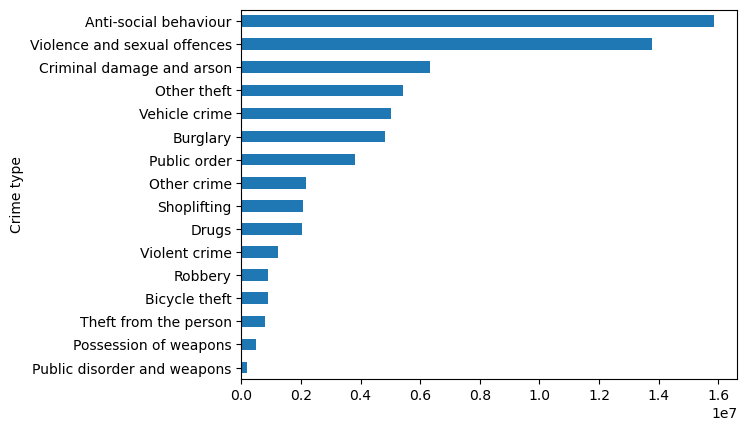

In [120]:
df['Crime type'].value_counts().sort_values(ascending=True).plot(kind='barh')

# 4. What about COVID vs rest?

In [142]:
# COVID period
covid_period = monthly_counts[
    (monthly_counts['year'] >= 2020) &
    (monthly_counts['year'] <= 2021)
]['crime_count']

# All other years
non_covid_period = monthly_counts[
    ((monthly_counts['year'] >= 2012) &
     (monthly_counts['year'] <= 2019)) |
    ((monthly_counts['year'] >= 2022) &
     (monthly_counts['year'] <= 2025))
]['crime_count']

In [144]:
ks_stat, ks_p = ks_2samp(
    covid_period,
    non_covid_period
)

print("KS Statistic:", ks_stat)
print("p-value:", ks_p)

KS Statistic: 0.22916666666666666
P-value: 0.2068796343939892


In [146]:
u_stat, mw_p = mannwhitneyu(
    covid_period,
    non_covid_period,
    alternative='two-sided'
)

print("U statistic:", u_stat)
print("p-value:", mw_p)

U statistic: 1953.0
P-value: 0.3088684763010202


In [148]:
print("COVID median:", covid_period.median())
print("Non-COVID median:", non_covid_period.median())

n1 = len(covid_period)
n2 = len(non_covid_period)

rbc = 1 - (2 * u_stat) / (n1 * n2)

print("Rank-biserial correlation:", rbc)

COVID median: 366882.5
Non-COVID median: 357641.5
Rank-biserial correlation: -0.13020833333333326


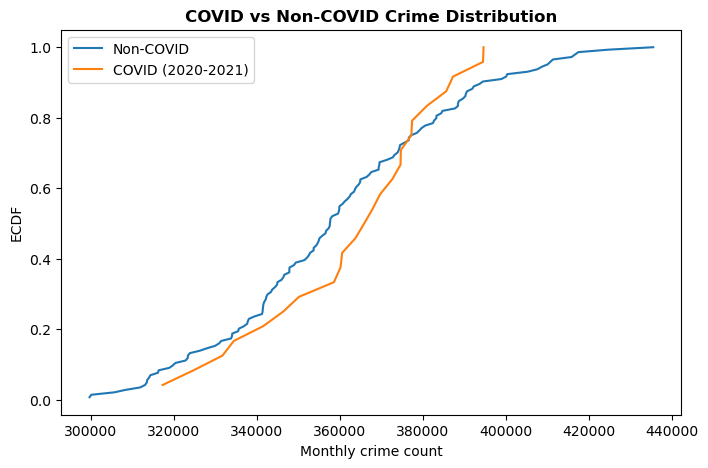

In [167]:
x1 = np.sort(non_covid_period)
y1 = np.arange(1, len(x1)+1) / len(x1)

x2 = np.sort(covid_period)
y2 = np.arange(1, len(x2)+1) / len(x2)

plt.figure(figsize=(8,5))

plt.plot(x1, y1, label='Non-COVID')
plt.plot(x2, y2, label='COVID (2020-2021)')

plt.xlabel('Monthly crime count')
plt.ylabel('ECDF')
plt.title('COVID vs Non-COVID Crime Distribution', weight='bold')

plt.legend()

plt.show()

### Findings
- There is insufficient evidence to conclude that the overall distribution of monthly crime counts during COVID differed significantly from the non-COVID years
- Unlike the  previous ECDF, there is no clear consistent left/right shift
- There is no statistically significant proof that COVID monthly crime counts were systematically higher or lower than non-COVID counts.
- The COVID median is actually slightly higher, but the statistical tests indicate that this difference is small relative to the variability, and not statistically reliable. So this could easily arise from normal variation
- The rank-biserial correlation score, which has a negative sign, is not very meaningful given the non-significant result and overlapping distributions
- The curves in the ECDF plot intersect, overlap substantially and lack a dominant shift direction. This visually shows why the two tests are not significant

**Possible interpretation**: it's not that COVID did not have an effect on crime, but that the total monthly crime counts, aggregated across all crime types, were not significantly different. It might be that some crime categories changed dramatically, but increases and decreases offset each other in the aggregate totals. This is extremely common in pandemic-era crime studies [LOOK FOR PAPERS, Rovshan's perchance]


# 5. Investigating crime-level variations 

In [185]:
monthly_counts = (
    df.groupby(['Month', 'Crime type'])
      .size()
      .reset_index(name='crime_count')
)

monthly_counts['year'] = monthly_counts['Month'].dt.year

In [187]:
covid_period = monthly_counts[
    (monthly_counts['year'] >= 2020) &
    (monthly_counts['year'] <= 2021)
]

non_covid_period = monthly_counts[
    ((monthly_counts['year'] >= 2012) & (monthly_counts['year'] <= 2019)) |
    ((monthly_counts['year'] >= 2022) & (monthly_counts['year'] <= 2025))
]

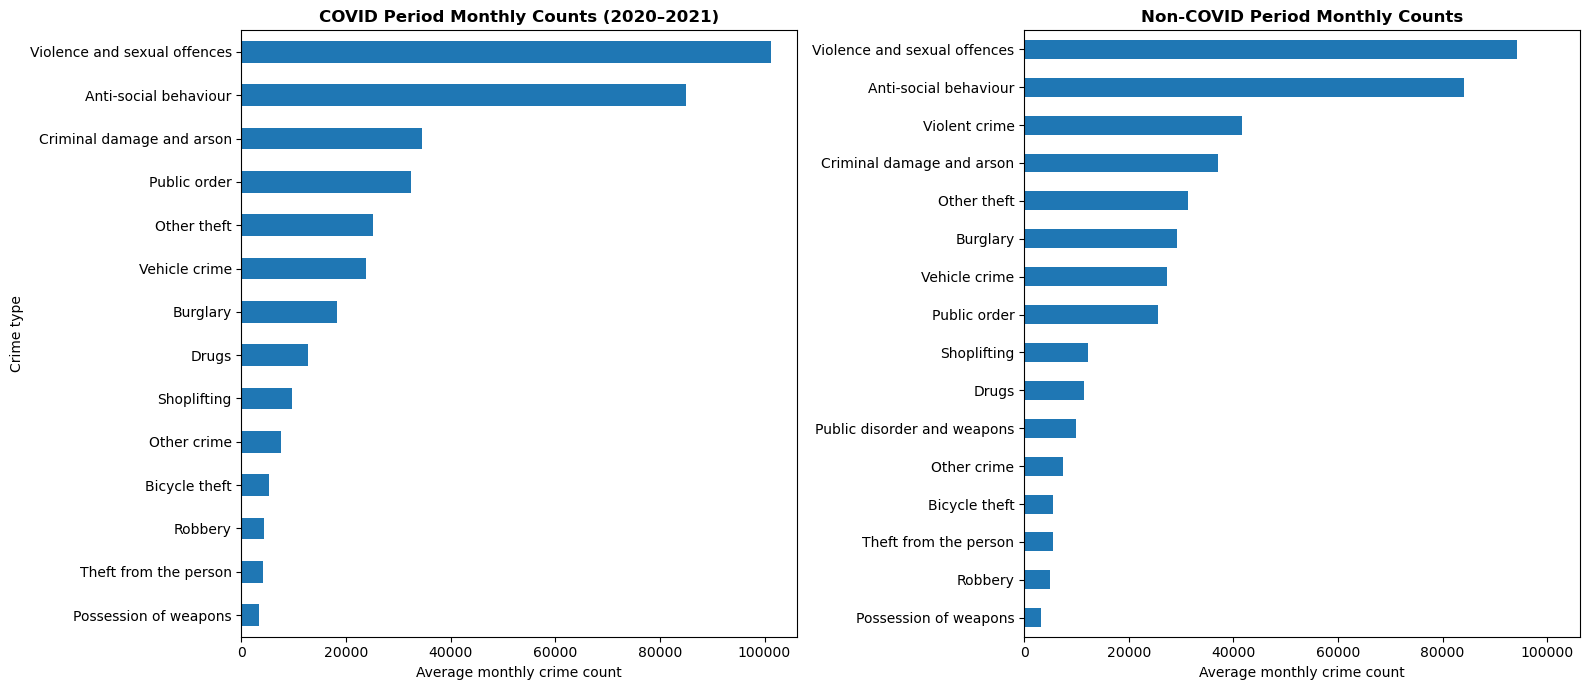

In [195]:
covid_counts = (
    covid_period.groupby('Crime type')['crime_count']
    .median()
    .sort_values()
)

non_covid_counts = (
    non_covid_period.groupby('Crime type')['crime_count']
    .median()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

covid_counts.plot(kind='barh', ax=axes[0])
axes[0].set_title('COVID Period Monthly Counts (2020–2021)', weight='bold')
axes[0].set_xlabel('Average monthly crime count')
axes[0].set_ylabel('Crime type')

non_covid_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Non-COVID Period Monthly Counts', weight='bold')
axes[1].set_xlabel('Average monthly crime count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [206]:
monthly_counts = (
    df.groupby(['Month', 'Crime type'])
      .size()
      .reset_index(name='crime_count')
)

monthly_counts['year'] = monthly_counts['Month'].dt.year

monthly_counts['period'] = monthly_counts['year'].apply(
    lambda y: 'COVID (2020-2021)' if 2020 <= y <= 2021 else 'Non-COVID'
)

category_medians = (
    monthly_counts
    .groupby(['period', 'Crime type'])['crime_count']
    .median()
    .reset_index()
)

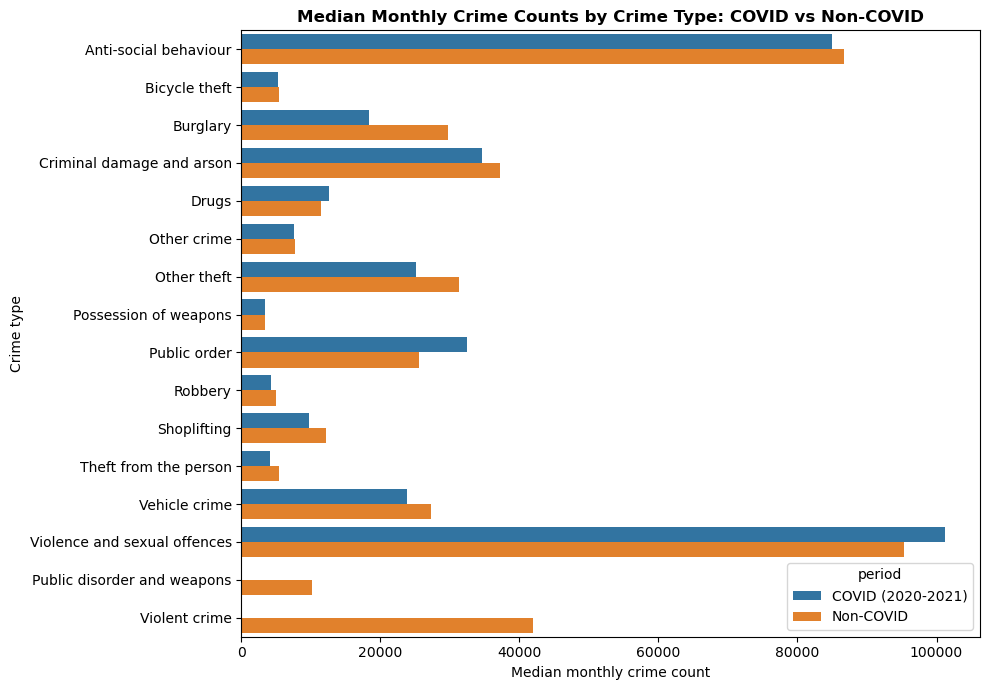

In [259]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=category_medians,
    y='Crime type',
    x='crime_count',
    hue='period'
)

plt.xlabel('Median monthly crime count')
plt.ylabel('Crime type')
plt.title('Median Monthly Crime Counts by Crime Type: COVID vs Non-COVID', weight='bold')
plt.tight_layout()
plt.show()

#### Short description

The plot shows slight increases in violence and sexual offences, public order and drugs. Potentially also possession of drugs and anti-social behaviour (roughly stable/slightly elevated) [NAH]. These categories are often associated with:

- Social stress
- Domestic environments
- Policing changes
- Lockdown enforcement
- Behavioural tensions

This might align well with pandemic era criminology literature.

On the other hand, the strongest decreases appear in burglary, theft from the person, shoplifting, vehicle crime, robbery, other theft; these are opportunity/mobility crimes. That is theoretically very plausible because lockdowns:

- Reduced movement,
- Closed shops/nightlife,
- Increased home occupancy,
- Reduced street interactions.

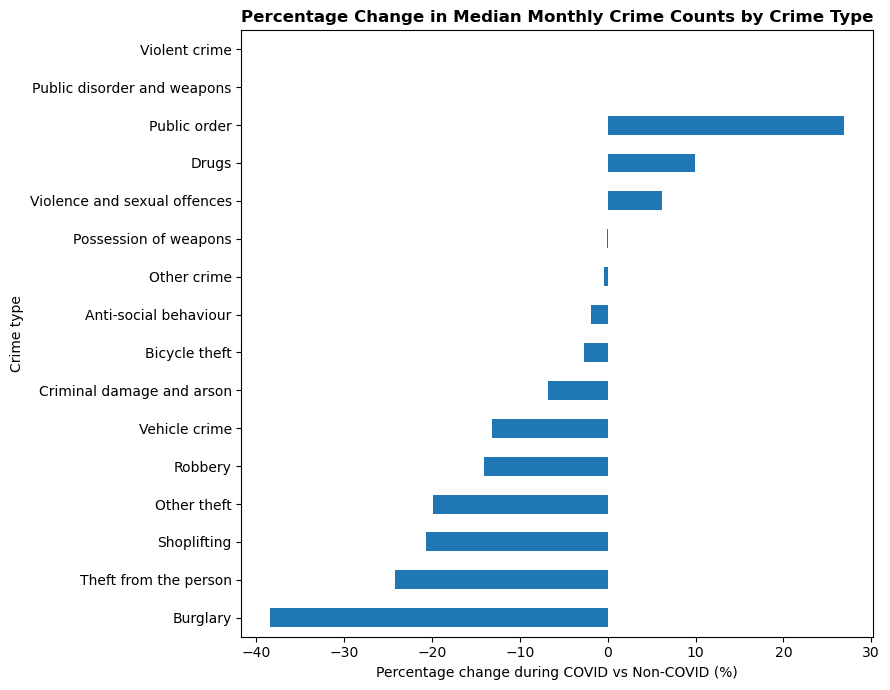

In [224]:
pivot = category_medians.pivot(
    index='Crime type',
    columns='period',
    values='crime_count'
)

pivot['percent_change'] = (
    (pivot['COVID (2020-2021)'] - pivot['Non-COVID']) 
    / pivot['Non-COVID'] * 100
)

pivot = pivot.sort_values('percent_change')

pivot['percent_change'].plot(kind='barh', figsize=(9,7))

plt.xlabel('Percentage change during COVID vs Non-COVID (%)')
plt.ylabel('Crime type')
plt.title('Percentage Change in Median Monthly Crime Counts by Crime Type', weight='bold')
plt.tight_layout()
plt.show()

#### Short description:
This plot answers directly to the question "which crimes changed most during COVID?". The decreases indicate strong reductions in acquisitive/property crimes during COVID, whereas the increases are linked to lockdown enforcement, social disturbances, behavioral conflicts, domestic violence,
reporting changes and altered social conditions. COVID appears to have redistributed crime rather than uniformly increasing or decreasing it.

Although aggregate monthly crime distributions did not differ significantly between COVID and non-COVID periods, crime-type analysis reveals substantial compositional changes during the pandemic. Property and opportunity-related offences such as burglary, theft, and shoplifting declined markedly, whereas public-order and violence-related offences increased. These offsetting category-level effects likely explain the absence of a significant aggregate difference.

N.B. Because the Mann–Whitney U test is a non-parametric rank-based test, median monthly crime counts were used for descriptive visualization to ensure consistency with the underlying statistical methodology.

In [226]:
for crime in df['Crime type'].unique():

    crime_df = monthly_counts[
        monthly_counts['Crime type'] == crime
    ]

    covid = crime_df[
        (crime_df['year'] >= 2020) &
        (crime_df['year'] <= 2021)
    ]['crime_count']

    non_covid = crime_df[
        ((crime_df['year'] >= 2012) &
         (crime_df['year'] <= 2019)) |
        ((crime_df['year'] >= 2022) &
         (crime_df['year'] <= 2025))
    ]['crime_count']

    if len(covid) > 0 and len(non_covid) > 0:

        u, p = mannwhitneyu(
            covid,
            non_covid,
            alternative='two-sided'
        )

        print(crime, p)

Shoplifting 1.7924478994707272e-13
Burglary 5.172382926887636e-06
Anti-social behaviour 0.987342431324176
Criminal damage and arson 0.00017308448551784972
Other theft 2.8494796754670415e-12
Robbery 0.0019032159665773388
Violence and sexual offences 0.03446341554819695
Vehicle crime 6.411589932432306e-06
Drugs 0.0023366313853561095
Bicycle theft 0.13607020230830033
Other crime 0.4572582239110594
Public order 1.1962327602230803e-05
Theft from the person 3.8008762765826645e-11
Possession of weapons 0.9456157315712534


#### Short description

Crime-type-specific Mann–Whitney U tests revealed significant compositional changes in crime during the COVID period. Significant differences were observed for shoplifting, burglary, criminal damage and arson, other theft, robbery, violence and sexual offences, vehicle crime, drugs, public order, and theft from the person (all p < 0.05), indicating that monthly counts for these offences tended to differ between COVID and non-COVID periods. In contrast, anti-social behaviour, bicycle theft, other crime, and possession of weapons did not show statistically significant differences, suggesting relatively stable monthly levels across periods. Together, these findings suggest that COVID altered the composition of crime more substantially than overall crime volume.